In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

In [2]:
# domain range
d01_range = ( 9.733, 33.868,  97.149, 131.277)  # (lat1, lat2, lon1, lon2)
d02_range = (15.873, 28.941, 105.287, 123.664)
d03_range = (20.117, 24.487, 111.150, 117.276)
d04_range = (21.697, 22.965, 113.338, 115.117)
d05_range = (22.139, 22.562, 113.824, 114.417)

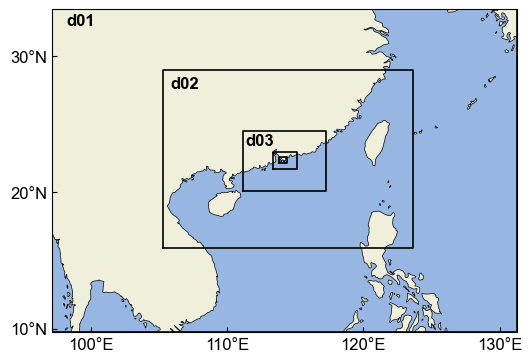

In [3]:
# plot d01-d05
# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

# create figure
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([d01_range[2], d01_range[3], d01_range[0], d01_range[1]-1.5])
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), lw=0.5)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN, zorder=1)

# set ticks
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.set_xticks(np.arange(100, 131, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 31, 10), crs=ccrs.PlateCarree())
ax.tick_params(direction='in')

domains = [
    ('d01', d01_range),
    ('d02', d02_range),
    ('d03', d03_range),
    ('d04', d04_range),
    ('d05', d05_range),
]

for domain_name, (lat1, lat2, lon1, lon2) in domains:
    lons = [lon1, lon2, lon2, lon1, lon1]
    lats = [lat1, lat1, lat2, lat2, lat1]
    ax.plot(
        lons,
        lats,
        color='black',
        linewidth=1.2,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    if domain_name in {'d01', 'd02', 'd03'}:
        x_offset = max((lon2 - lon1) * 0.03, 0.08)
        y_offset = max((lat2 - lat1) * 0.03, 0.08)
        ax.text(
            lon1 + x_offset,
            lat2 - y_offset,
            domain_name,
            color='black',
            fontweight='bold',
            ha='left',
            va='top',
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

plt.savefig('./wrf_d01_d05.tif', dpi=600, bbox_inches='tight')

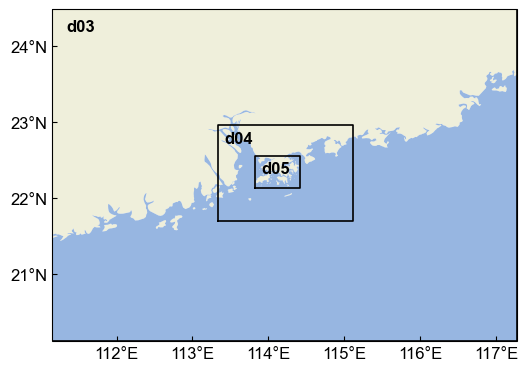

In [ ]:
# plot d03-d05
# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

# create figure
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([d03_range[2], d03_range[3], d03_range[0], d03_range[1]])
# ax.add_feature(cfeature.COASTLINE.with_scale('10m'), lw=0.5)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN, zorder=1)

# set ticks
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.set_xticks(np.arange(112, 118, 1), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(21, 25, 1), crs=ccrs.PlateCarree())
ax.tick_params(direction='in')

# plot domains
domains = [
    ('d03', d03_range),
    ('d04', d04_range),
    ('d05', d05_range),
]

for domain_name, (lat1, lat2, lon1, lon2) in domains:
    lons = [lon1, lon2, lon2, lon1, lon1]
    lats = [lat1, lat1, lat2, lat2, lat1]
    ax.plot(
        lons,
        lats,
        color='black',
        linewidth=1.2,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    x_offset = max((lon2 - lon1) * 0.03, 0.08)
    y_offset = max((lat2 - lat1) * 0.03, 0.08)
    ax.text(
        lon1 + x_offset,
        lat2 - y_offset,
        domain_name,
        color='black',
        fontweight='bold',
        ha='left',
        va='top',
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

plt.savefig('./output/wrf_d03_d05.tif', bbox_inches='tight')